# Exploratory Clustering — *why* KAAPAV is classification, not clustering

**VALOR NLP layer · supports the report's 'critical thinking' section**

The stakeholder originally framed this as a *clustering* task. The KAAPAV
Developer Reference (Sec. 3 + Sec. 6 'expectation management') argues it is a
**sequence-labelling problem over a known, ordered taxonomy** — unsupervised
clustering only weakly recovers the known phases and cannot replace supervised
classification.

This notebook *demonstrates that empirically*: we embed the segments, run
KMeans (k=6), and measure alignment with both phase and topic labels.
The results (PHASE ARI=0.222, NMI=0.340 vs TOPIC ARI=0.008, NMI=0.108) show
that clustering recovers phase structure only weakly — and the near-zero topic
scores reflect a degenerate topic tagger that labels 91% of segments as
"Allgemein", not a meaningful signal. Taken together, this confirms that
supervised classification with a phase-ordering prior is the correct framing.


## 0. Setup


In [1]:
!pip install -q sentence-transformers scikit-learn seaborn umap-learn


In [2]:
import json, pathlib, numpy as np, pandas as pd
ROOT=pathlib.Path('valor-nlp-layer')  # adjust in Colab
if not (ROOT/'data'/'synthetic_transcripts.jsonl').exists():
    from google.colab import files
    up=files.upload(); ROOT=pathlib.Path('.'); (ROOT/'data').mkdir(exist_ok=True)
    import os
    for fn in up: os.replace(fn, ROOT/'data'/fn)
def load_jsonl(p): return [json.loads(l) for l in open(p,encoding='utf-8') if l.strip()]
segs=load_jsonl(ROOT/'data'/'synthetic_transcripts.jsonl')+load_jsonl(ROOT/'data'/'gold_eval.jsonl')
df=pd.DataFrame(segs); print(len(df),'segments'); df['phase'].value_counts()


Saving gold_eval.jsonl to gold_eval.jsonl
Saving synthetic_transcripts.jsonl to synthetic_transcripts.jsonl
1679 segments


,count
phase,
Angebot,376
Pruefung,370
Analyse,338
Abschluss,228
Kontakt,220
Verstaerkung,147


## 1. Tag each segment with a *topic* (product family)
So we can test whether clusters track topic or phase.


In [3]:
PRODUCTS={'bauspar':'Bausparen','baufinanz':'Immobilie','immobil':'Immobilie',
  'tagesgeld':'Sparen','festgeld':'Sparen','sparbuch':'Sparen','sparplan':'Sparen',
  'riester':'Vorsorge','rürup':'Vorsorge','ruerup':'Vorsorge','rente':'Vorsorge',
  'fonds':'Wertpapier','investment':'Wertpapier','depot':'Wertpapier',
  'versicher':'Versicherung','berufsunf':'Versicherung','lebensvers':'Versicherung',
  'kredit':'Kredit','giro':'Konto'}
def topic(t):
    t=t.lower()
    for k,v in PRODUCTS.items():
        if k in t: return v
    return 'Allgemein'
df['topic']=df['text'].map(topic)
df['topic'].value_counts()


,count
topic,
Allgemein,1525
Sparen,62
Vorsorge,30
Versicherung,20
Wertpapier,18
Kredit,18
Bausparen,4
Immobilie,2


## 2. Embed segments (German/multilingual sentence-transformer)


In [4]:
from sentence_transformers import SentenceTransformer
enc=SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
X=enc.encode(df['text'].tolist(), show_progress_bar=True, normalize_embeddings=True)
X.shape


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/53 [00:00<?, ?it/s]

(1679, 384)

## 3. KMeans (k=6) and compare to phase vs. topic
If clustering recovered phases, ARI/NMI vs phase would be high. We observe only weak agreement (ARI≈0.22), so KMeans does not reconstruct the phase taxonomy.

In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score as ARI, normalized_mutual_info_score as NMI
km=KMeans(n_clusters=6, n_init=10, random_state=0).fit(X)
df['cluster']=km.labels_
print('Agreement of KMeans clusters with ...')
print(f"  PHASE : ARI={ARI(df['phase'],df['cluster']):.3f}  NMI={NMI(df['phase'],df['cluster']):.3f}")
print(f"  TOPIC : ARI={ARI(df['topic'],df['cluster']):.3f}  NMI={NMI(df['topic'],df['cluster']):.3f}")


Agreement of KMeans clusters with ...
  PHASE : ARI=0.222  NMI=0.340
  TOPIC : ARI=0.008  NMI=0.108


## 4. Cluster composition heatmaps
Read the rows: a clean phase-clusterer would put each phase in one column.


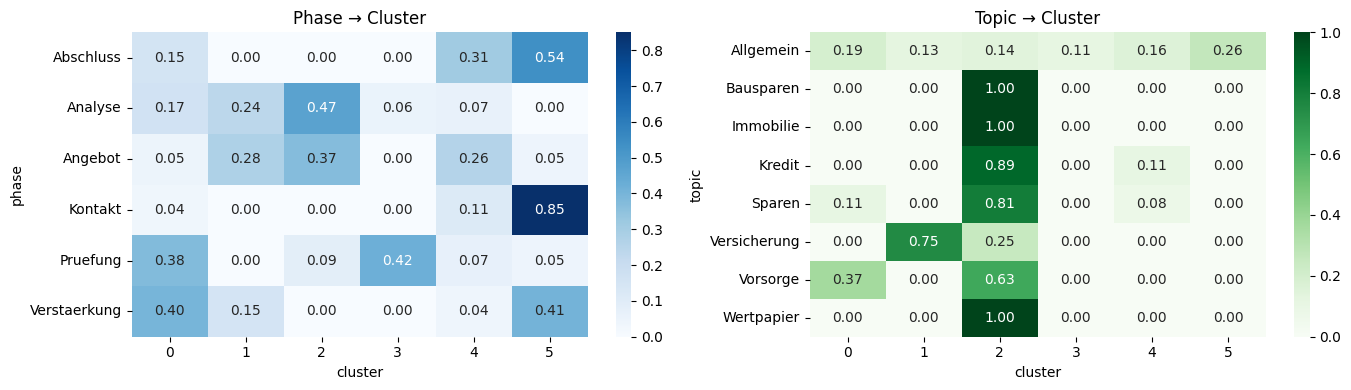

In [6]:
import seaborn as sns, matplotlib.pyplot as plt
fig,ax=plt.subplots(1,2,figsize=(14,4))
sns.heatmap(pd.crosstab(df['phase'],df['cluster'],normalize='index'),
            annot=True,fmt='.2f',cmap='Blues',ax=ax[0]); ax[0].set_title('Phase → Cluster')
sns.heatmap(pd.crosstab(df['topic'],df['cluster'],normalize='index'),
            annot=True,fmt='.2f',cmap='Greens',ax=ax[1]); ax[1].set_title('Topic → Cluster')
plt.tight_layout(); plt.show()


## 5. 2-D projection coloured by phase vs. cluster vs. topic


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


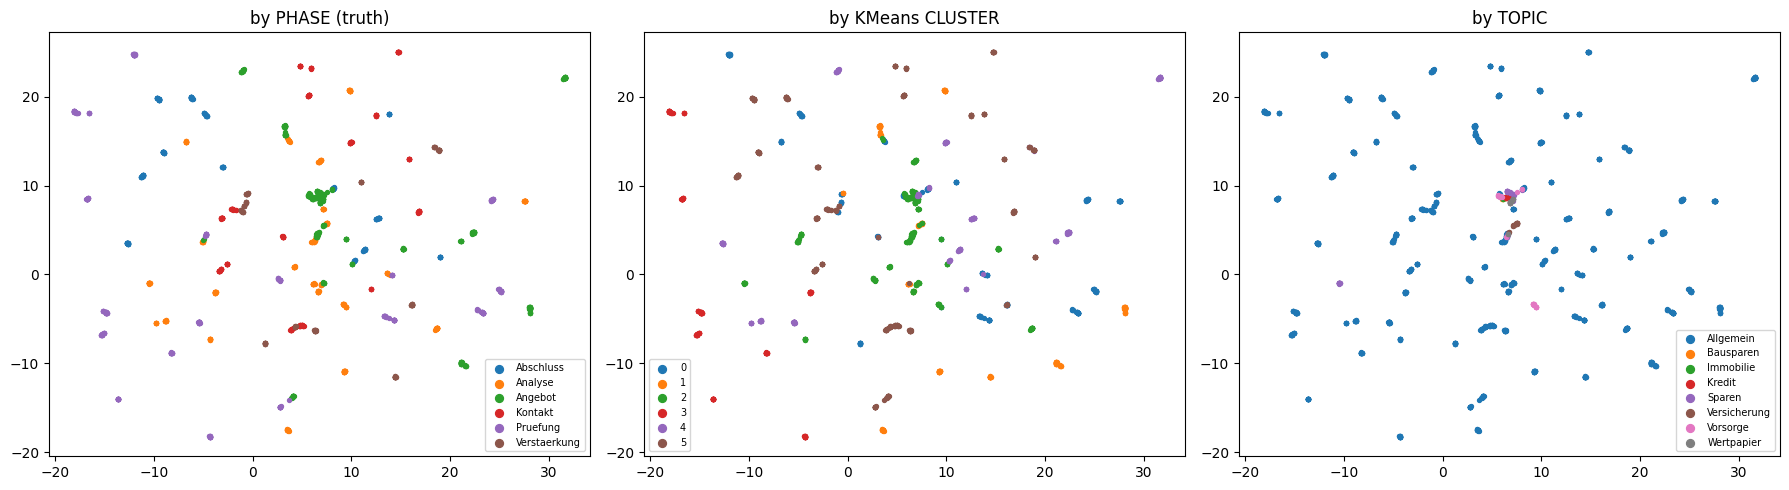

In [7]:
import umap, matplotlib.pyplot as plt
emb2=umap.UMAP(n_neighbors=15,min_dist=0.1,random_state=0).fit_transform(X)
df['u0'],df['u1']=emb2[:,0],emb2[:,1]
fig,ax=plt.subplots(1,3,figsize=(18,5))
for a,col,t in zip(ax,['phase','cluster','topic'],['by PHASE (truth)','by KMeans CLUSTER','by TOPIC']):
    for v,g in df.groupby(col): a.scatter(g['u0'],g['u1'],s=8,label=str(v))
    a.set_title(t); a.legend(fontsize=7,markerscale=2)
plt.tight_layout(); plt.show()


## 6. Conclusion

The measured numbers support the report claim that *unsupervised clustering does not
recover the KAAPAV phases*: KMeans recovers phase structure only weakly
(PHASE ARI=0.222, NMI=0.340). The near-zero topic agreement (ARI=0.008) is a
degenerate-tagger artifact — the keyword tagger labels 91% of segments as
"Allgemein" — and is **not** evidence of a topic confound. Either way, unsupervised
clustering is insufficient on its own.

This is the empirical justification for framing the deliverable as supervised
phase **classification** with an order prior (notebook 01 + the CPU pipeline),
while keeping clustering only as the exploratory / weak-supervision step the
reference describes.
